# Decision Tree Classification


## Assignment Explanation

### Objective
The objective of this assignment is to build a Decision Tree classification model and evaluate its performance on the heart disease dataset.

### Methodology
The dataset is explored for missing values, column types, and summary statistics. The target column is separated from the input features. Numerical columns are imputed with median values and categorical columns are imputed and encoded. The dataset is split into training and testing sets.

A Decision Tree classifier is trained, and hyperparameter tuning is performed using GridSearchCV. The best model is evaluated using classification metrics such as precision, recall, F1-score, and confusion matrix.

### Interpretation
A Decision Tree is easy to interpret because it splits the data using feature-based rules. The evaluation metrics show how well the model predicts the target class and whether it makes more false positives or false negatives.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid')
pd.set_option('display.max_columns', None)

sns.set(style='whitegrid')
pd.set_option('display.max_columns', None)


In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,accuracy_score,mean_squared_error,f1_score

xls=pd.ExcelFile("heart_disease.xlsx")
for sheet in xls.sheet_names:
    df=pd.read_excel("heart_disease.xlsx",sheet_name=sheet)
    print(sheet)
    print(df.head())


Description
        age                                       Age in years
0    Gender                       Gender ; Male - 1, Female -0
1        cp                                    Chest pain type
2  trestbps                             Resting blood pressure
3      chol                                cholesterol measure
4       fbs  (fasting blood sugar > 120 mg/dl) (1 = true; 0...
Heart_disease
   age   sex               cp  trestbps  chol    fbs         restecg  thalch  \
0   63  Male   typical angina       145   233   True  lv hypertrophy     150   
1   41  Male  atypical angina       135   203  False          normal     132   
2   57  Male     asymptomatic       140   192  False          normal     148   
3   52  Male   typical angina       118   186  False  lv hypertrophy     190   
4   57  Male     asymptomatic       110   201  False          normal     126   

   exang  oldpeak        slope          thal  num  
0  False      2.3  downsloping  fixed defect    0  
1  False   

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [4]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [6]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [7]:
df.shape

(908, 13)

In [8]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(1)

In [10]:
df['oldpeak']=df['oldpeak'].fillna(df['oldpeak'].mean)

In [11]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

#  Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the structure and characteristics of the dataset before applying machine learning algorithms.

EDA helps in:
- understanding feature distributions
- identifying missing values
- detecting outliers
- analysing relationships between variables

Visualization techniques such as histograms, box plots, and correlation matrices are used for better understanding of the dataset.

# 📈 Histogram Visualization

Histograms are used to visualize the distribution of numerical features.

This helps in understanding:
- frequency distribution
- skewness of variables
- spread of data values

Histograms provide a clear overview of feature distributions within the dataset.

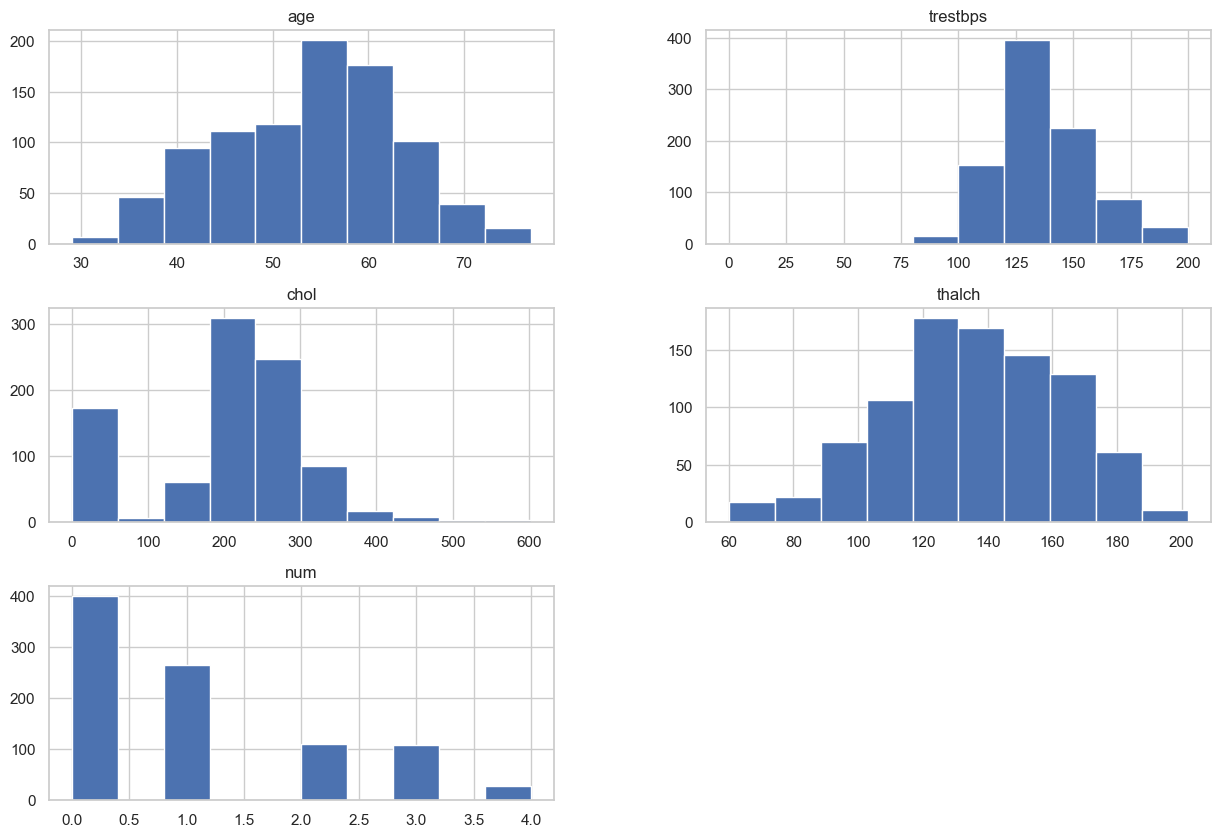

In [12]:
df.hist(figsize=(15,10))
plt.show()

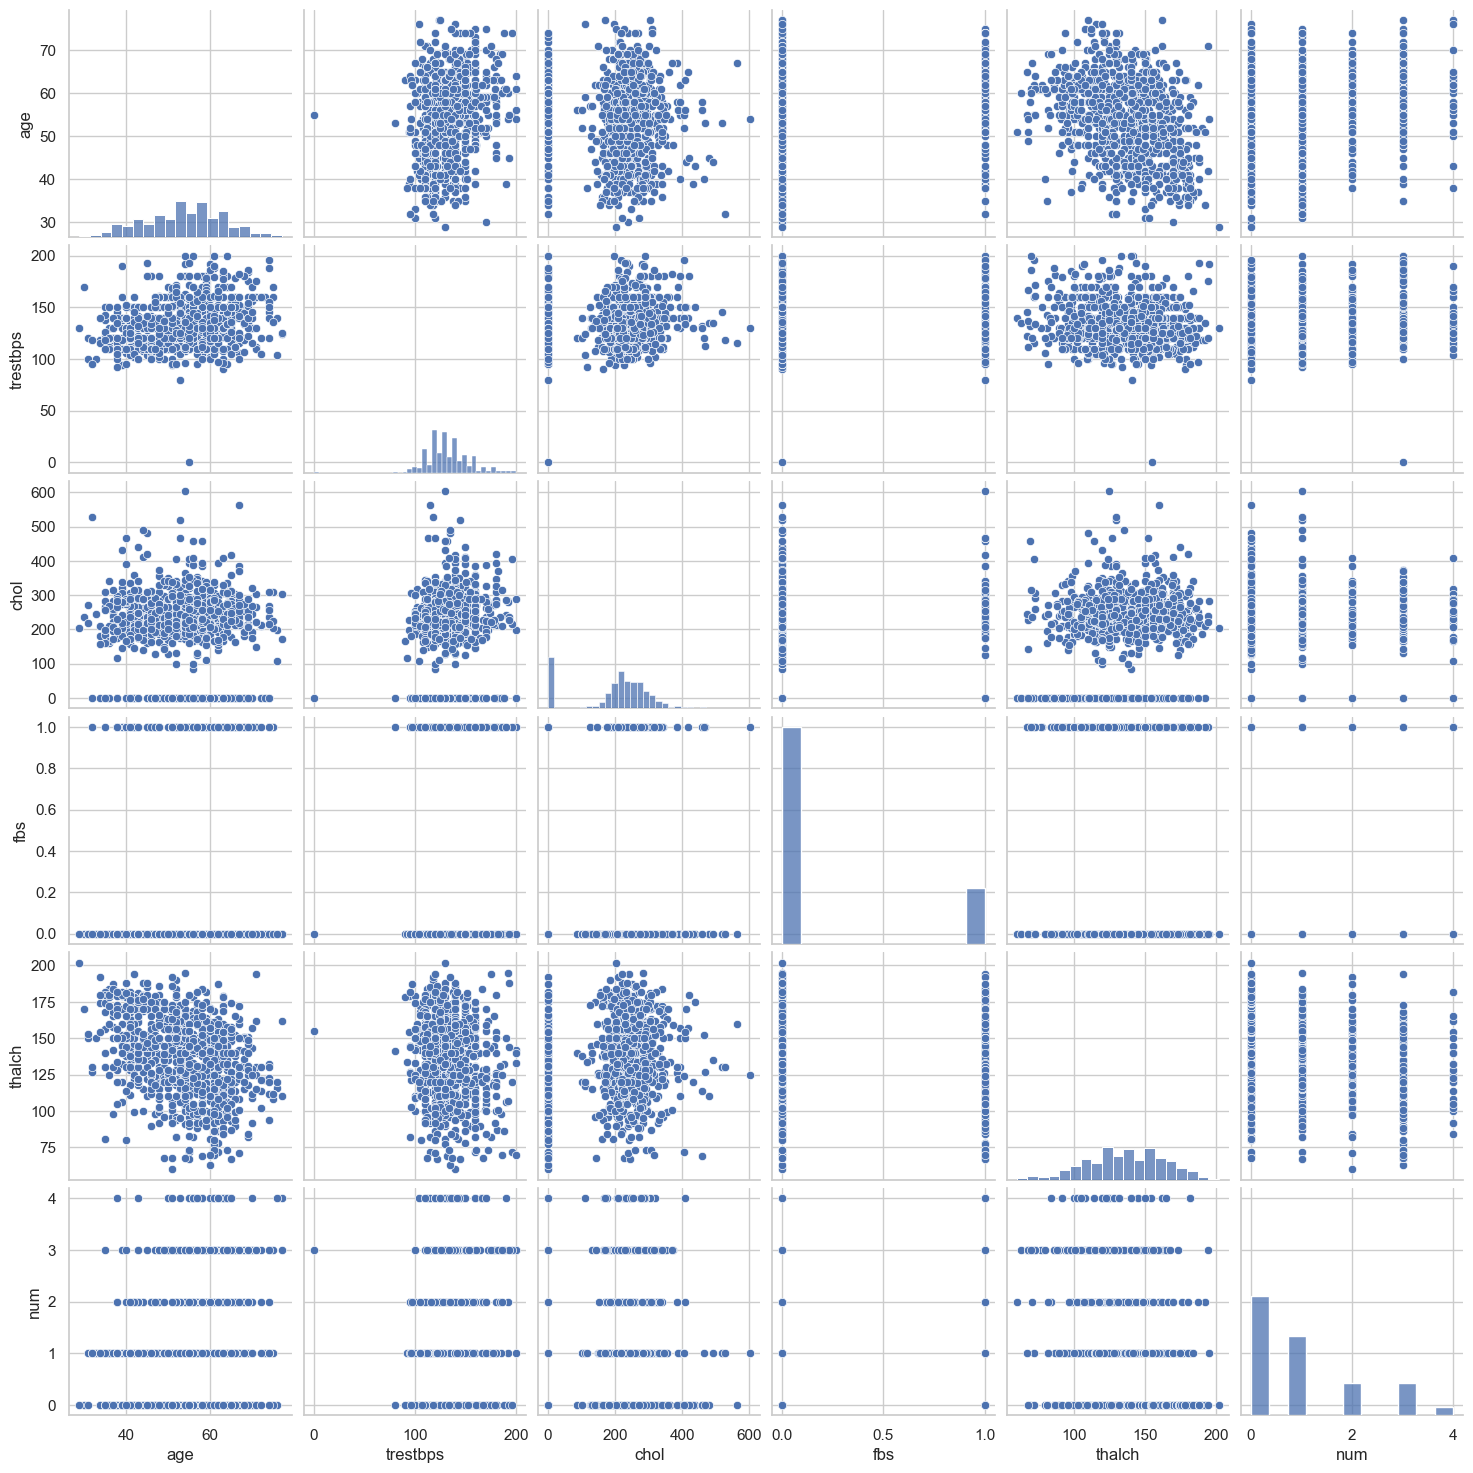

In [13]:
sns.pairplot(data=df)
plt.show()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       908 non-null    int64 
 1   sex       908 non-null    object
 2   cp        908 non-null    object
 3   trestbps  908 non-null    int64 
 4   chol      908 non-null    int64 
 5   fbs       908 non-null    bool  
 6   restecg   908 non-null    object
 7   thalch    908 non-null    int64 
 8   exang     908 non-null    object
 9   oldpeak   908 non-null    object
 10  slope     908 non-null    object
 11  thal      908 non-null    object
 12  num       908 non-null    int64 
dtypes: bool(1), int64(5), object(7)
memory usage: 86.1+ KB


#  Feature Engineering

Feature engineering is performed to prepare the dataset for machine learning.

This process may include:
- encoding categorical variables
- scaling numerical features
- handling missing values

Feature engineering improves data quality and model performance.

In [15]:
num_cols=df.select_dtypes(include=['int64','float64']).columns
cat_cols=df.select_dtypes(include=['object']).columns
num_cols
cat_cols
df[cat_cols]=df[cat_cols].astype(str)

In [16]:
le=LabelEncoder()
for cat in cat_cols:
    df[cat]=le.fit_transform(df[cat])
df['fbs']=le.fit_transform(df['fbs'])
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,1,0,150,1,33,0,0,0
1,41,1,1,135,203,0,1,132,1,10,1,0,0
2,57,1,0,140,192,0,1,148,1,14,1,0,0
3,52,1,3,118,186,0,0,190,1,10,1,0,0
4,57,1,0,110,201,0,1,126,3,25,1,0,0


# Correlation Matrix

The correlation matrix measures the relationship between variables in the dataset.

It helps identify:
- positive correlations
- negative correlations
- highly related features

Understanding feature relationships improves feature selection and model interpretation.

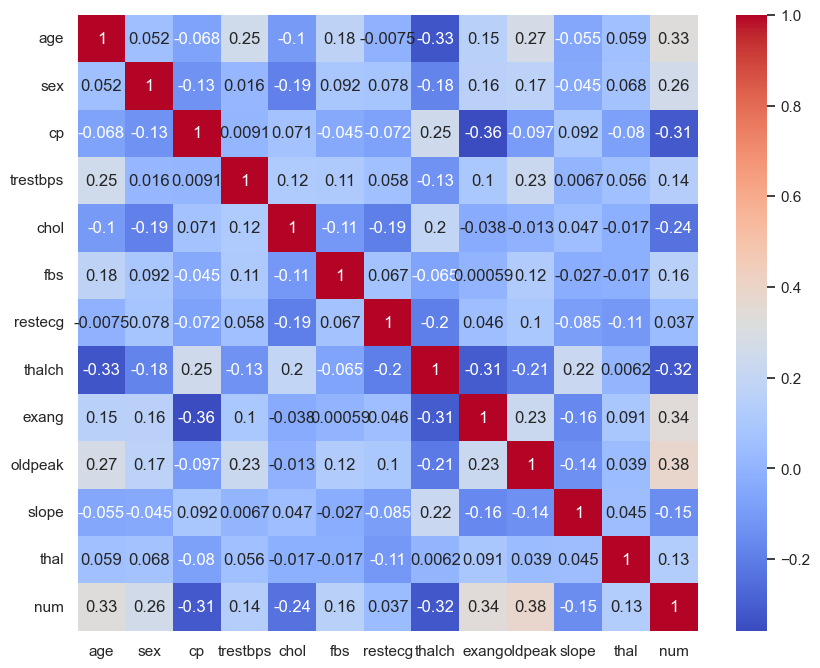

In [17]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

# Box Plot Visualization

Box plots are used to identify outliers and analyse the spread of the data.

Outliers are extreme observations that may affect model performance and prediction accuracy.

Box plots also display:
- median values
- quartiles
- variability of data

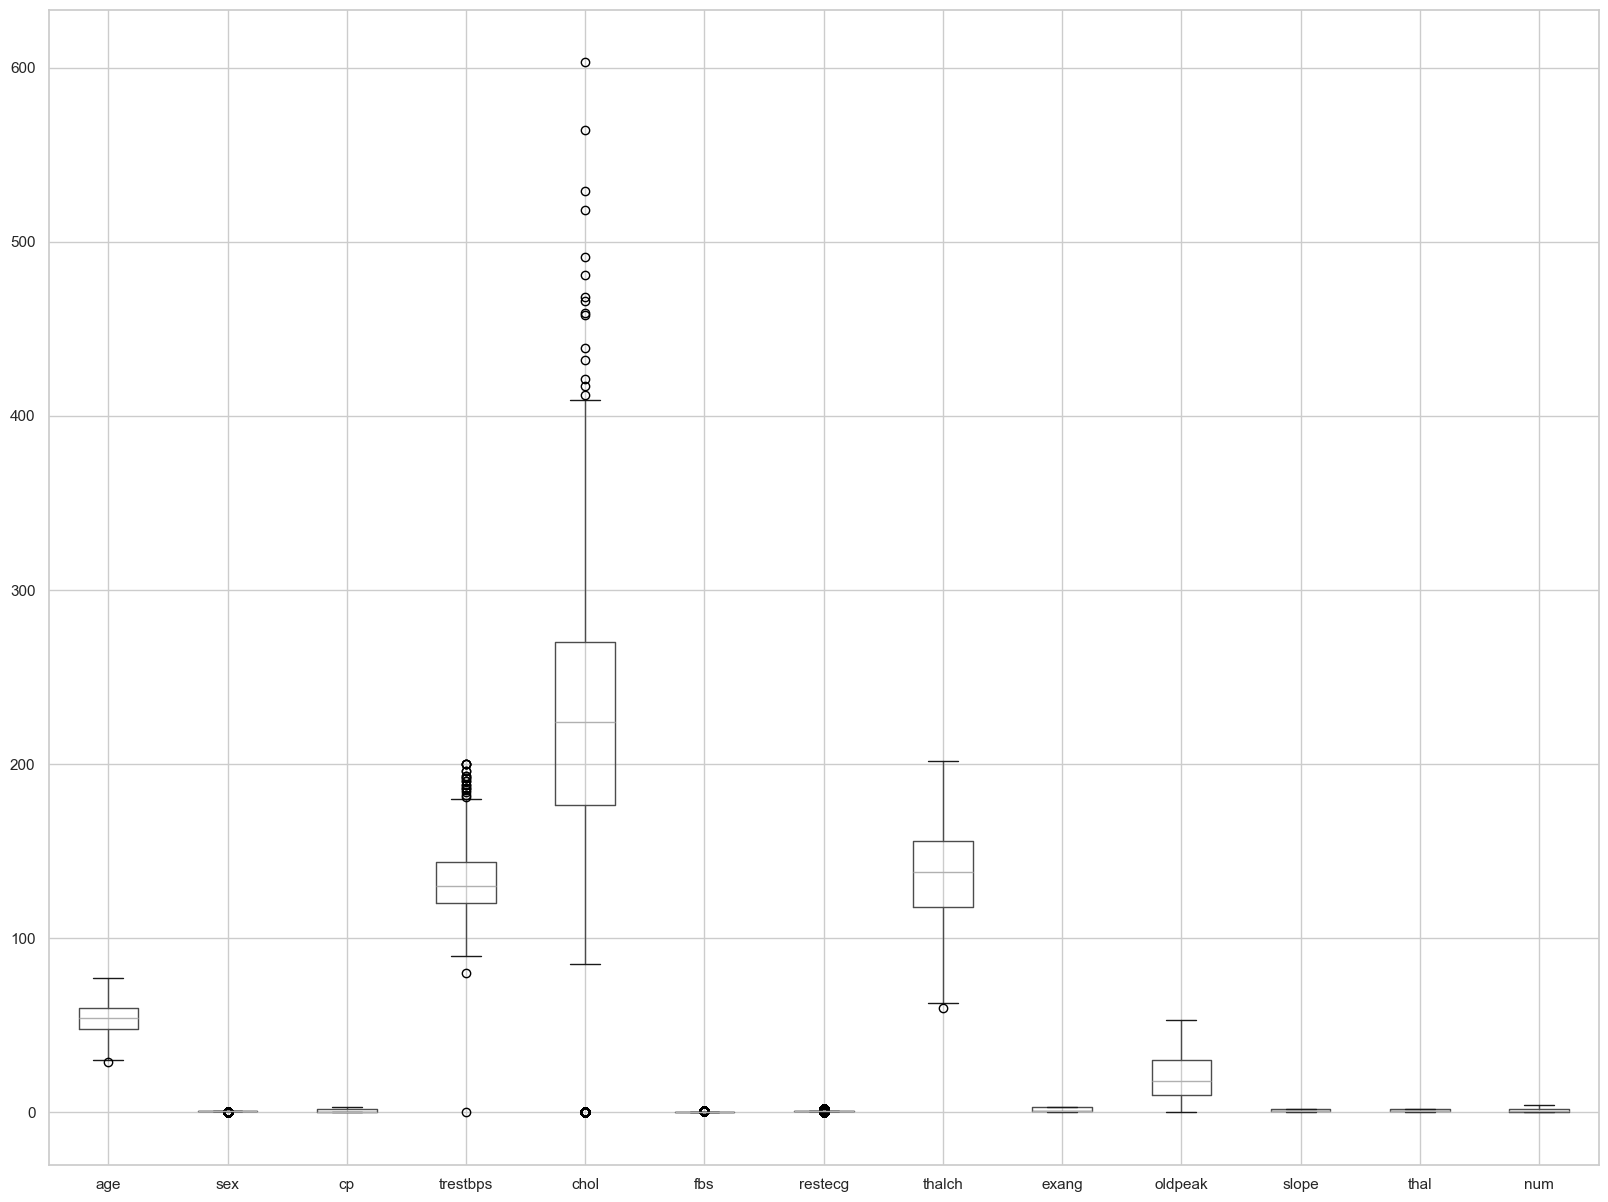

In [18]:
df.boxplot(figsize=(20,15))
plt.show()

In [19]:
df.skew()

age        -0.136797
sex        -1.431902
cp          0.795836
trestbps    0.353650
chol       -0.564766
fbs         1.473485
restecg     0.007213
thalch     -0.219555
exang       0.360492
oldpeak     1.051064
slope      -0.214870
thal       -0.309485
num         0.951409
dtype: float64

In [20]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,1,0,150,1,33,0,0,0
1,41,1,1,135,203,0,1,132,1,10,1,0,0
2,57,1,0,140,192,0,1,148,1,14,1,0,0
3,52,1,3,118,186,0,0,190,1,10,1,0,0
4,57,1,0,110,201,0,1,126,3,25,1,0,0


In [21]:
X=df.drop('num',axis=1)
y=df['num']
ss=StandardScaler()
scale_X=ss.fit_transform(X)
scale_X

array([[ 1.00602683,  0.51441613,  2.32027607, ...,  0.89967451,
        -1.6727697 , -1.61585234],
       [-1.39756029,  0.51441613,  0.23225756, ..., -0.84601001,
        -0.22484321, -1.61585234],
       [ 0.35050307,  0.51441613, -0.81175169, ..., -0.5424127 ,
        -0.22484321, -1.61585234],
       ...,
       [ 0.24124911,  0.51441613,  1.27626682, ...,  1.05147317,
        -1.6727697 , -0.25481902],
       [ 0.24124911,  0.51441613,  1.27626682, ...,  2.41766106,
        -1.6727697 , -1.61585234],
       [ 0.35050307,  0.51441613, -0.81175169, ...,  2.41766106,
        -0.22484321,  1.10621431]], shape=(908, 12))

#  Splitting the Dataset

The dataset is divided into:
- training data
- testing data

An 80-20 split is commonly used:
- 80% for training
- 20% for testing

Training data is used to train the model, while testing data is used to evaluate performance on unseen data.

In [22]:
train_x,test_x,train_y,test_y=train_test_split(scale_X,y,test_size=0.2,random_state=42)

# Decision Tree Classification

Decision Tree is a supervised machine learning algorithm used for classification problems.

The model creates a tree-like structure where:
- internal nodes represent conditions
- branches represent decision paths
- leaf nodes represent output classes

The algorithm learns classification rules from the training dataset and predicts target classes based on those rules.
# Model Training

The Decision Tree model is trained using the training dataset.

During training, the model learns relationships between:
- input features
- target classes

The algorithm identifies the best splitting conditions that improve classification accuracy.

In [23]:
model=DecisionTreeClassifier()
model.fit(train_x,train_y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# Model Prediction

After training, the model predicts target values for the testing dataset.

These predictions are compared with actual values to measure the effectiveness of the model on unseen data.
# Model Evaluation

The performance of the Decision Tree model is evaluated using various evaluation metrics such as:
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

These metrics help analyse prediction quality and classification performance.

In [24]:
y_predict=model.predict(train_x)
y_test=model.predict(test_x)
training_accuracy=accuracy_score(train_y,y_predict)
testing_accuracy=accuracy_score(test_y,y_test)
print("training accuracy: ",training_accuracy)
print("testing accuracy: ",testing_accuracy)
cr=classification_report(test_y,y_test)
print("classification report: ", cr)
cm=confusion_matrix(test_y,y_test)
print("confusion matrix: ",cm)
y_prob = best_model.predict_proba(test_x)

roc = roc_auc_score(
    test_y,
    y_prob,
    multi_class='ovr'
)

print("ROC-AUC Score:", roc)

training accuracy:  1.0
testing accuracy:  0.5604395604395604
classification report:                precision    recall  f1-score   support

           0       0.78      0.74      0.76        89
           1       0.45      0.50      0.48        48
           2       0.24      0.27      0.26        22
           3       0.40      0.35      0.38        17
           4       0.00      0.00      0.00         6

    accuracy                           0.56       182
   macro avg       0.37      0.37      0.37       182
weighted avg       0.57      0.56      0.56       182

confusion matrix:  [[66 13  4  4  2]
 [12 24  9  3  0]
 [ 5  7  6  2  2]
 [ 2  7  2  6  0]
 [ 0  2  4  0  0]]


NameError: name 'best_model' is not defined

# Hyperparameter Tuning

Hyperparameter tuning is performed to optimize model performance.

Parameters such as:
- maximum depth
- minimum samples split
- criterion

are adjusted to identify the best-performing model configuration.

GridSearchCV is commonly used for hyperparameter optimization.

In [ ]:
params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3,5,7,10],
    'min_samples_split': [2,5,10]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=params,
    cv=5
)

grid.fit(train_x, train_y)

In [ ]:
print(grid.best_params_)

In [ ]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(test_x)

print("Best Accuracy:",
      accuracy_score(test_y, y_pred_best))

#  Decision Tree Visualization

The Decision Tree structure is visualized to understand:
- decision rules
- feature conditions
- class predictions

Visualization improves interpretability and helps understand how the model makes predictions.

In [ ]:
plt.figure(figsize=(20,10))

plot_tree(
    best_model,
    filled=True,
    feature_names=X.columns,
    class_names=['0','1','2','3','4']
)

plt.show()

# Feature Importance

Feature importance analysis identifies the most influential variables affecting predictions.

Features with higher importance values contribute more significantly to the classification process.

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

# Interview Question 1

## What are some common hyperparameters of Decision Tree models, and how do they affect the model's performance?

Decision Tree models contain several hyperparameters that control how the tree is built and how it performs during classification.

### Common Hyperparameters:

### 1. max_depth
The `max_depth` parameter controls the maximum depth of the Decision Tree.

- Large depth may cause overfitting
- Small depth may cause underfitting

A balanced depth improves generalization and model accuracy.

---

### 2. min_samples_split
This parameter defines the minimum number of samples required to split a node.

- Smaller values create more splits
- Larger values reduce unnecessary splitting

It helps control model complexity and prevents overfitting.

---

### 3. min_samples_leaf
This parameter specifies the minimum number of samples required in a leaf node.

Higher values make the model more generalized and stable.

---

### 4. criterion
The `criterion` parameter measures the quality of a split.

Common criteria:
- `gini`
- `entropy`

### Gini Index
Measures impurity in the dataset.

### Entropy
Measures information gain during splitting.

---

### 5. max_features
This parameter controls the number of features considered during splitting.

It helps reduce overfitting and improves model efficiency.

---

## Effect on Model Performance

Hyperparameters directly affect:
- model accuracy
- overfitting
- underfitting
- tree complexity
- prediction performance

Proper hyperparameter tuning improves:
- model generalization
- classification accuracy
- prediction reliability

# Interview Question 2

## What is the difference between Label Encoding and One-Hot Encoding?

Label Encoding and One-Hot Encoding are techniques used to convert categorical data into numerical format for machine learning models.

---

# Label Encoding

Label Encoding converts each category into a unique numerical value.

### Example:

| Color | Encoded Value |
|---|---|
| Red | 0 |
| Blue | 1 |
| Green | 2 |

### Advantages:
- Simple and memory efficient
- Suitable for ordinal data

### Disadvantages:
- Creates an artificial order between categories
- May affect some machine learning algorithms

---

# 🧩 One-Hot Encoding

One-Hot Encoding creates separate binary columns for each category.

### Example:

| Color | Red | Blue | Green |
|---|---|---|---|
| Red | 1 | 0 | 0 |
| Blue | 0 | 1 | 0 |
| Green | 0 | 0 | 1 |

### Advantages:
- Removes artificial ordering
- Suitable for nominal categorical data

### Disadvantages:
- Increases dimensionality
- Requires more memory

---

# 📌 Difference Between Label Encoding and One-Hot Encoding

| Label Encoding | One-Hot Encoding |
|---|---|
| Converts categories into numerical labels | Creates separate binary columns |
| Suitable for ordinal data | Suitable for nominal data |
| Memory efficient | Higher memory usage |
| May introduce order relationship | Removes ordering problem |

---

## Conclusion

Both encoding techniques are important in machine learning preprocessing.

- Label Encoding is preferred for ordinal categorical variables.
- One-Hot Encoding is preferred for nominal categorical variables where no order exists between categories.